<a href="https://colab.research.google.com/github/NataliiaHromyk/HomeWork_Python_DS/blob/main/Hromyk_%22HW_2_5_Time_Series_Analysis_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('drive/MyDrive/ML_files/train.csv.zip')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df2 = pd.read_csv('drive/MyDrive/ML_files/train.csv.zip')

In [3]:
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [4]:
df['date'] = pd.to_datetime(df['date'])

In [5]:
df.set_index('date', inplace=True)

In [6]:
df[:10]

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



In [7]:
import pandas as pd
import matplotlib.pyplot as plt

***Середній продаж по кожному айтему (з min–max діапазоном)***

In [8]:
group_item = df.groupby(["date","item"])["sales"].agg(["mean","min","max",'count']).reset_index()
group_item


,date,item,mean,min,max,count
0,2013-01-01,1,13.3,7,20,10
1,2013-01-01,2,32.7,21,43,10
2,2013-01-01,3,17.2,9,26,10
3,2013-01-01,4,10.2,4,21,10
4,2013-01-01,5,8.3,4,13,10
...,...,...,...,...,...,...
91295,2017-12-31,46,60.5,35,79,10
91296,2017-12-31,47,21.1,12,29,10
91297,2017-12-31,48,49.4,32,64,10
91298,2017-12-31,49,28.5,12,44,10


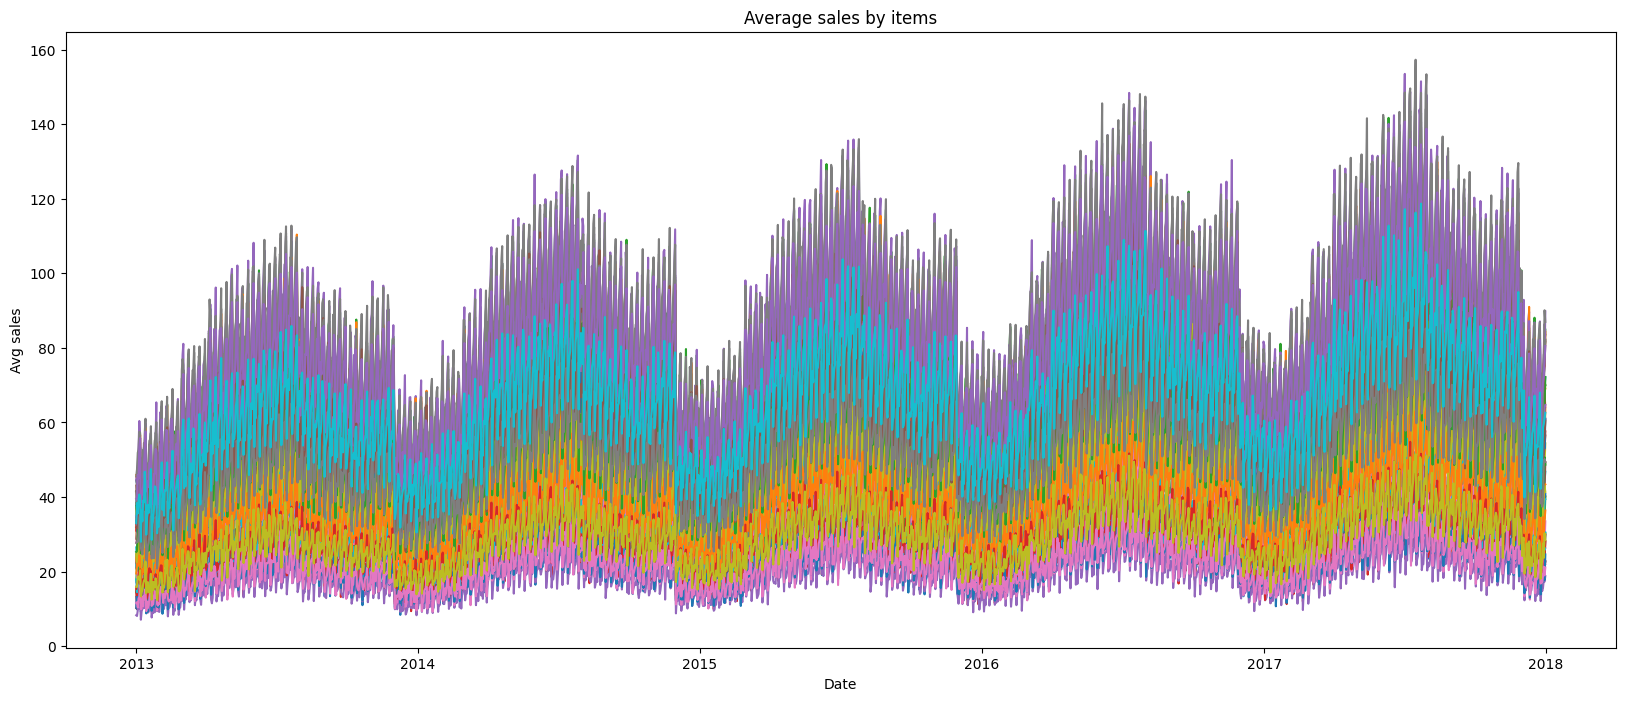

In [9]:
plt.figure(figsize=(20, 8))
for item_id in group_item["item"].unique():
    subset = group_item[group_item["item"] == item_id]
    plt.plot(subset["date"], subset["mean"], label=f"Item {item_id}")
plt.title("Average sales by items")
plt.xlabel("Date")
plt.ylabel("Avg sales")
plt.show()

***Середній продаж по магазинах (усі айтеми разом)***

In [10]:
group_store = df.groupby(["date", "store"])["sales"].mean().reset_index()
group_store

,date,store,sales
0,2013-01-01,1,26.32
1,2013-01-01,2,34.84
2,2013-01-01,3,31.76
3,2013-01-01,4,28.46
4,2013-01-01,5,20.64
...,...,...,...
18255,2017-12-31,6,40.18
18256,2017-12-31,7,36.62
18257,2017-12-31,8,64.10
18258,2017-12-31,9,55.48


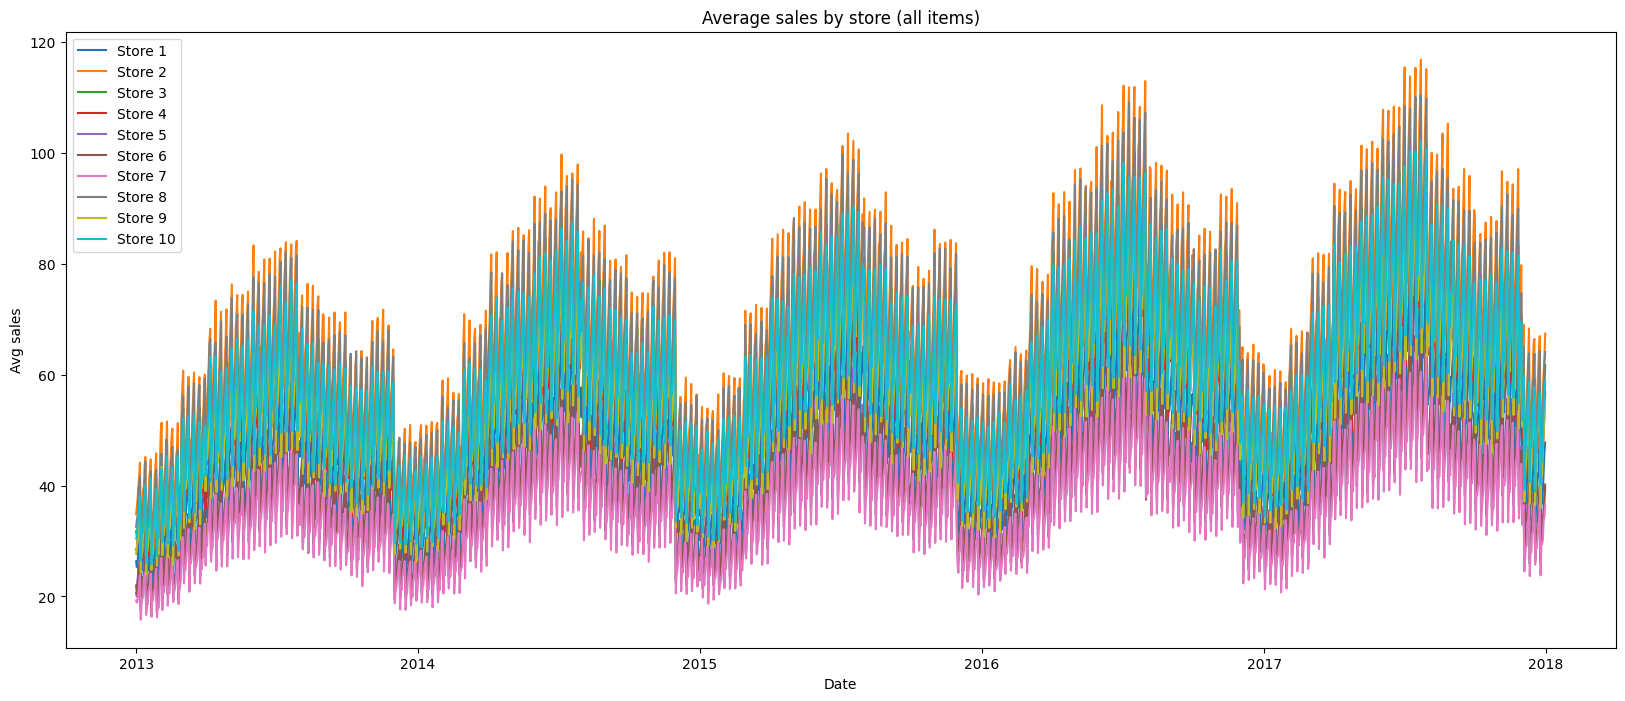

In [11]:
plt.figure(figsize=(20, 8))
for store_id in group_store["store"].unique():
    subset = group_store[group_store["store"] == store_id]
    plt.plot(subset["date"], subset["sales"], label=f"Store {store_id}")
plt.title("Average sales by store (all items)")
plt.xlabel("Date")
plt.ylabel("Avg sales")
plt.legend()
plt.show()

***Boxplot: розподіл продажів по айтемах (усі магазини)***

<Figure size 1400x600 with 0 Axes>

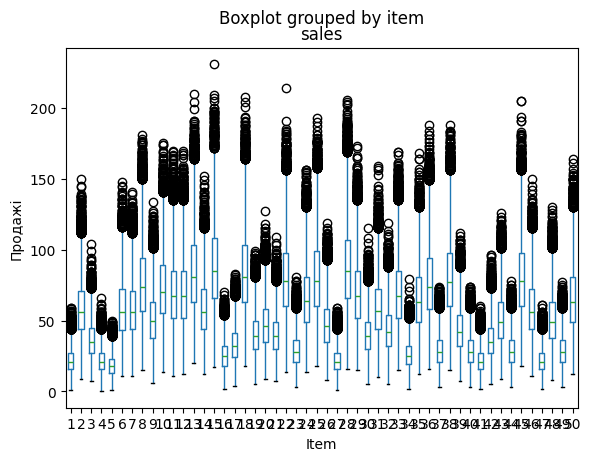

In [12]:
plt.figure(figsize=(14, 6))
df.boxplot(column="sales", by="item", grid=False)
plt.xlabel("Item")
plt.ylabel("Продажі")
plt.show()

Boxplot: розподіл продажів по магазинам (усі айтеми)

<Figure size 1400x600 with 0 Axes>

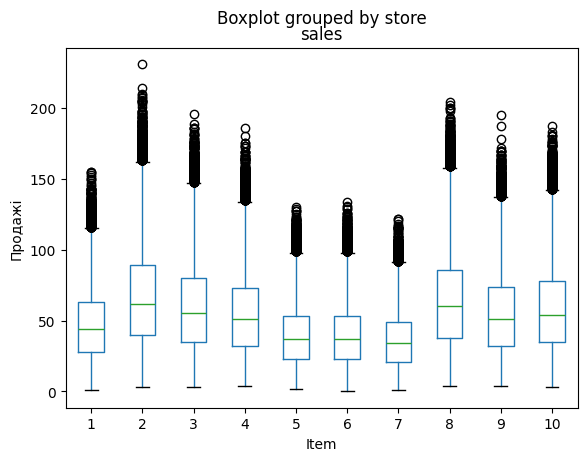

In [13]:
plt.figure(figsize=(14, 6))
df.boxplot(column="sales", by="store", grid=False)
plt.xlabel("Item")
plt.ylabel("Продажі")
plt.show()

По середньому показнику ціни спостерігаємо сезонні зміни - дану динаміку видно що по айтемах, що по магазинах. Окрім цього, завдяки боксплоту можна вдало зрозуміти, що ціна по кожному товарту доволі сильно відрізняється, тоді як по магазинам присутнє не настільки сильне відхилення по ціні(хоча, для прикладу у магазині 5-7 найнижчі показники ціни, бо викидів не такі високі як в інших)

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

In [14]:
df_additive =  df[(df["item"] == 1) & (df["store"] == 1)].copy(deep=True)

# рахуємо тренд згладжуючи ряд з річним вікном розміром 13
df_additive["trend"] = df_additive["sales"].rolling(window=13, center=True).mean()

# віднімаємо тренд з даних
df_additive["detrended"] = df_additive["sales"] - df_additive["trend"]

# рахуємо сезонну складову як середнє значення ряду пілся віднімання тренду
df_additive["month"] = df_additive.index.month
df_additive["seasonality"] = df_additive.groupby("month")["detrended"].transform("mean")

# обчислюємо залишок як все, що ми не змогли пояснити сезонністю
df_additive["resid"] = df_additive["detrended"] - df_additive["seasonality"]

# що у нас вийшло в результаті
df_additive.head(15)

,store,item,sales,trend,detrended,month,seasonality,resid
date,,,,,,,,
2013-01-01,1,1,13,NaN,NaN,1,-0.091895,NaN
2013-01-02,1,1,11,NaN,NaN,1,-0.091895,NaN
2013-01-03,1,1,14,NaN,NaN,1,-0.091895,NaN
2013-01-04,1,1,13,NaN,NaN,1,-0.091895,NaN
2013-01-05,1,1,10,NaN,NaN,1,-0.091895,NaN
2013-01-06,1,1,12,NaN,NaN,1,-0.091895,NaN
2013-01-07,1,1,10,10.692308,-0.692308,1,-0.091895,-0.600413
2013-01-08,1,1,9,10.615385,-1.615385,1,-0.091895,-1.523490
2013-01-09,1,1,12,10.153846,1.846154,1,-0.091895,1.938049


<Axes: xlabel='date'>

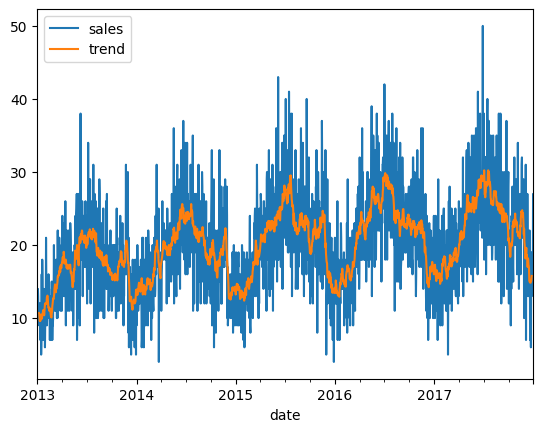

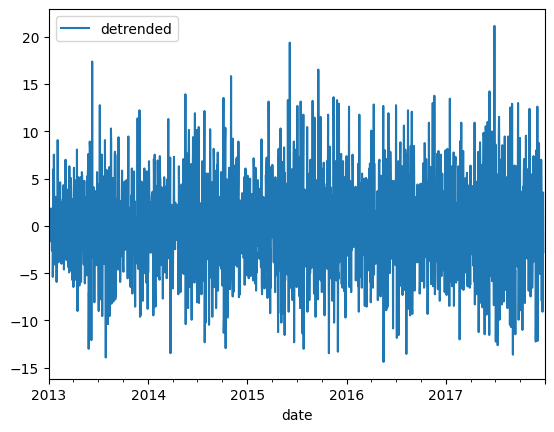

In [15]:
df_additive["trend_26"] = df_additive["sales"].rolling(window=26, center=True).mean()
df_additive[["sales", "trend"]].plot()
df_additive[["detrended"]].plot()

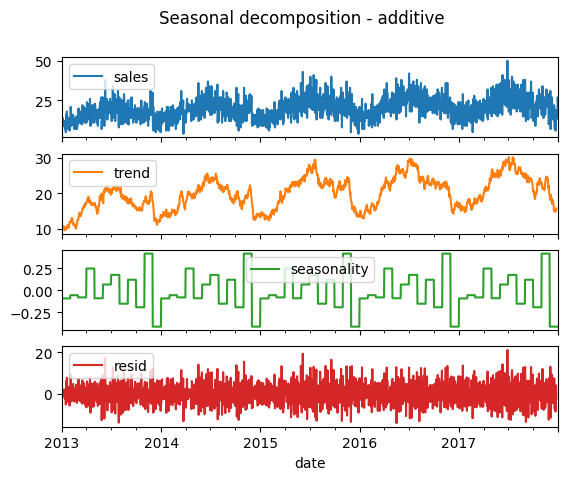

In [16]:
(
    df_additive
    .loc[:, ["sales", "trend", "seasonality", "resid"]]
    .plot(subplots=True, title="Seasonal decomposition - additive")
);

In [17]:
df_1_store_item = df[(df["item"] == 1) & (df["store"] == 1)]
df_1_store_item[:5]

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10


In [18]:
?seasonal_decompose

Object `seasonal_decompose` not found.


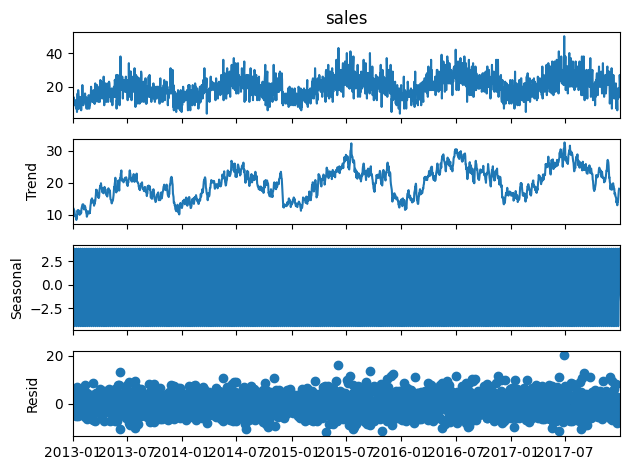

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Візуалізація адитивної декомпозиції для часового ряду
decomposition_plot_add = seasonal_decompose(df_1_store_item["sales"],
                                              model='additive')
decomposition_plot_add.plot()
plt.show()

Коректний варіант, який враховує період

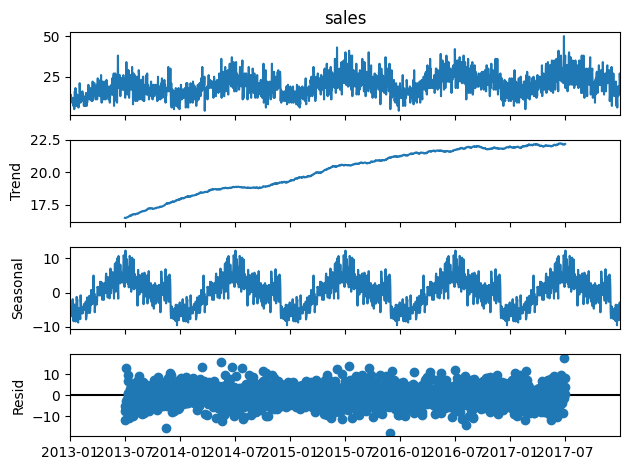

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Візуалізація адитивної декомпозиції для часового ряду
decomposition_plot_add = seasonal_decompose(df_1_store_item["sales"],
                                              model='additive',
                                              period = 365)
decomposition_plot_add.plot()
plt.show()

Взагалі в результатах побудови адативної моделі не вдавалось коректно переглянути показники сезонності, саме тому використала поле період, адже у нас дані поденні і це дозволяє моделі чітко визначити можливий період для даної метрики. З вашого дозволу залишу попередній варіант без періоду, щоб розуміти в майбутньому, як він впливає на показники.

Завдяки використанню періоду у даній адитивній моделі маємо:
1. Тренд: чітке зростання продажів з 2013 по 2017 рік - це означає, що попит на товар зростає
2. Сезонність: присутні регулярні коливання: тобто, в середині року попит зростає, а взимку спадає (це може бути, наприклад, морозиво, квас, пиво і тд)
3. Ресидуали: являються досить рівномірними, але присуині незначні викиди: це можуть бути якісь акції, наприклад

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [21]:
!pip install darts --quiet

In [22]:
?TimeSeries.from_dataframe

Object `TimeSeries.from_dataframe` not found.


In [23]:
from darts import TimeSeries

# Завантаження даних в darts, індекс був перетворений в Darts індекс автоматично
series = TimeSeries.from_dataframe(df_1_store_item,
                                   value_cols='sales',
                                   freq='D')

In [24]:
series

<TimeSeries (date: 1826, component: 1, sample: 1)> Size: 15kB
array([[[13.]],

       [[11.]],

       [[14.]],

       ...,

       [[15.]],

       [[27.]],

       [[23.]]])
Coordinates:
  * date       (date) datetime64[ns] 15kB 2013-01-01 2013-01-02 ... 2017-12-31
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

<Axes: xlabel='date'>

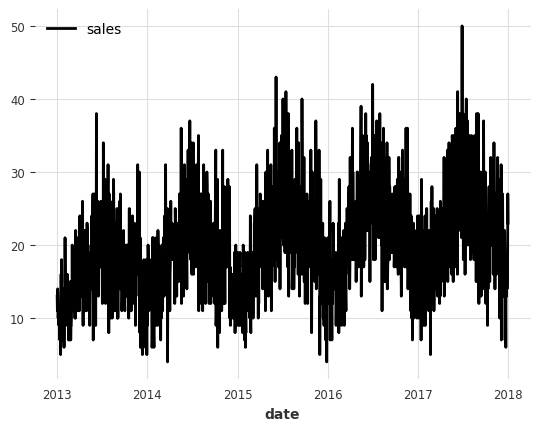

In [25]:
series.plot()

5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

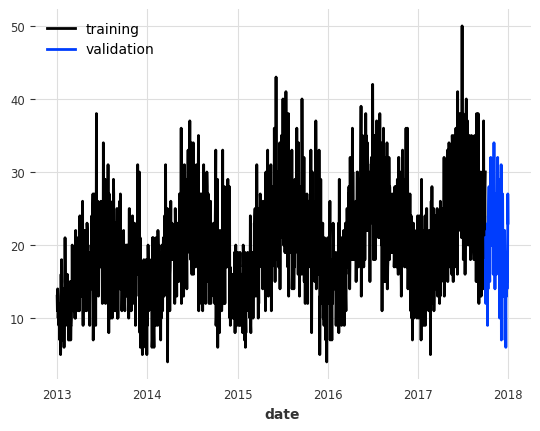

In [26]:
train, val = series.split_before(pd.Timestamp("2017-10-01"))
train.plot(label="training")
val.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

In [27]:
from darts.utils.missing_values import fill_missing_values

In [28]:
#Перевіряємо, чи всі дати йдуть підряд
expected_range = pd.date_range(start=df_1_store_item.index.min(),
                               end=df_1_store_item.index.max(),
                               freq="D")
missing_dates = expected_range.difference(df_1_store_item.index)

print("Кількість пропущених дат:", len(missing_dates))
print("Приклади:", missing_dates[:10])

Кількість пропущених дат: 0
Приклади: DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [29]:
?plot_acf

Object `plot_acf` not found.


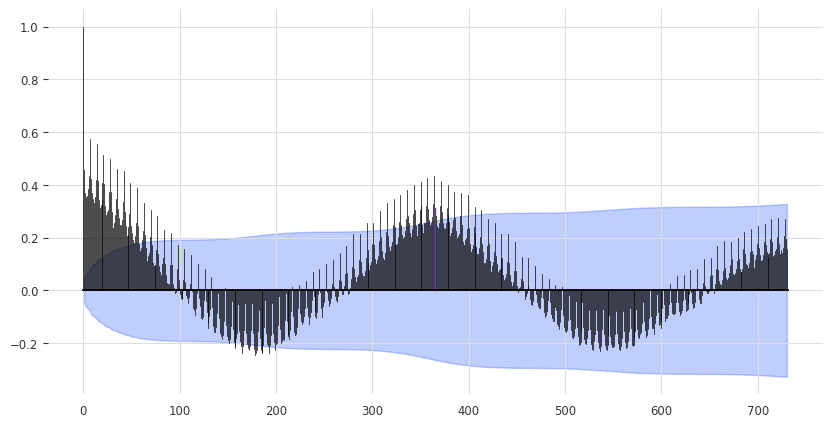

In [30]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=365, alpha=0.05, max_lag=730)

Із графіку вище чітко помітна річна сезоальність, тобто, 365 лаг. Але і окрім цього бачимо такі випуклості схожі на 7 день - пропоную це перевірити

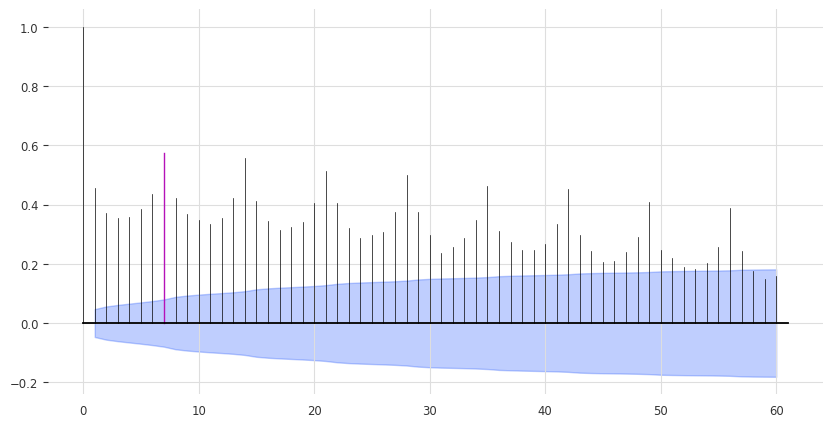

In [31]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=7, alpha=0.05, max_lag=60)

і дійсно, спостерігається і тижнева сезональність

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [32]:
?check_seasonality

In [33]:
check_seasonality(train, alpha=0.03)

(True, np.int64(7))

In [34]:
for m in (7,30,31,365):#range(2,750):
    is_seasonal, period = check_seasonality(train, m=m, alpha=0.05, max_lag=750)
    if is_seasonal:
        print("There is seasonality of order {}.".format(period))

There is seasonality of order 7.


присутня тижнева сезонність у даному часовому ряді, хоча і річна також міститься, проте в статистиці ми її не бачимо

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

In [35]:
len(val)

92

In [59]:
?NaiveSeasonal

<Axes: xlabel='date'>

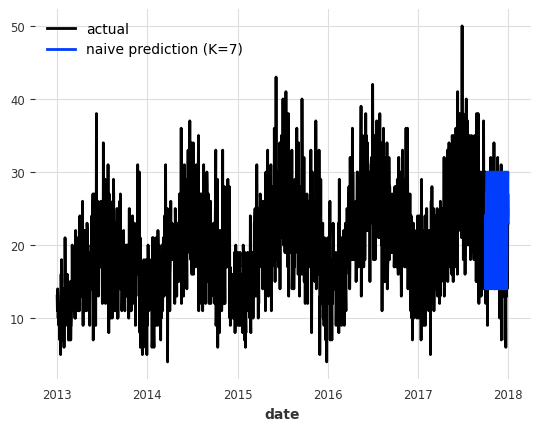

In [65]:
from darts.models import NaiveSeasonal

seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(92)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=7)")

In [66]:
forecast = seasonal_model.predict(len(val))
eval_forecast(seasonal_model, val, forecast);

model NaiveSeasonal(K=7) obtains MAPE: 38.17%


Викоритовуючи тижневу сезонність наївна модель прогнозує погано, оскільки період предікту рівен 92, що в 13 разів перебільшує показник тежневої сезонності(7). У такому випадку після 7 значень модель просто дублюватиме показники на валідаційних даних і це формуватиме помилку
У такому випадку пропоную відібрати 365 днів - річний показник сезонності

<Axes: xlabel='date'>

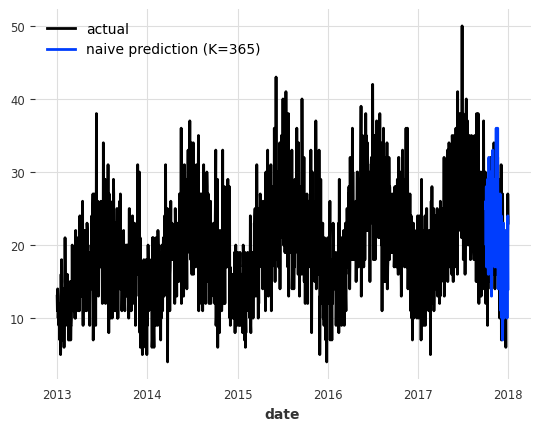

In [67]:
from darts.models import NaiveSeasonal

seasonal_model = NaiveSeasonal(K=365)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(92)

series.plot(label="actual")
seasonal_forecast.plot(label="naive prediction (K=365)")

In [68]:
forecast = seasonal_model.predict(len(val))
eval_forecast(seasonal_model, val, forecast);

model NaiveSeasonal(K=365) obtains MAPE: 33.92%


При даному показнику ми дійсно помічаємо позитивні зрушення

<Axes: xlabel='date'>

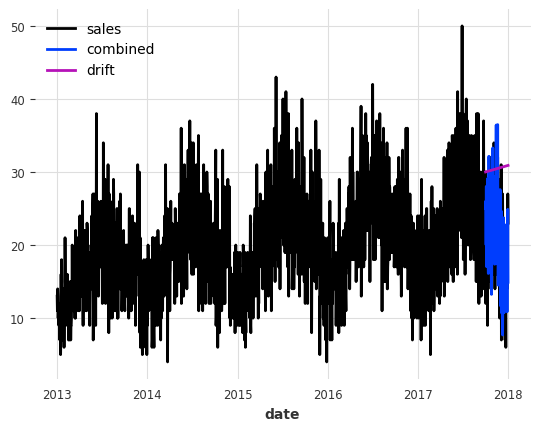

In [69]:
from darts.models import NaiveDrift

drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(92)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label="combined")
drift_forecast.plot(label="drift")

In [70]:
forecast = drift_model.predict(len(val))
eval_forecast(drift_model, val, forecast);

model NaiveDrift() obtains MAPE: 68.74%


NaiveDrift подібна із NaiveSeasonal, але  з річною сезональністю

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [40]:
from darts.metrics import mape

print(
    f"Mean absolute percentage error for the combined naive drift + seasonal: {mape(series, combined_forecast):.2f}%."
)

Mean absolute percentage error for the combined naive drift + seasonal: 34.26%.


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [41]:
def eval_forecast(model, val, forecast):
  mape_ = mape(val, forecast)
  print(f"model {model} obtains MAPE: {mape_:.2f}%")
  return mape_

In [42]:
import pandas as pd

In [43]:
train.to_dataframe()

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-09-26,18.0
2017-09-27,27.0
2017-09-28,23.0


In [44]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
import numpy as np

def enrich_with_date_features(df):
  # Feature Extraction
  # df["hour"] = df['Month'].dt.hour
  df["dayofweek"] = df['date'].dt.dayofweek
  df["quarter"] = df['date'].dt.quarter
  df["month"] = df['date'].dt.month
  df["year"] = df['date'].dt.year
  df["dayofyear"] = df['date'].dt.dayofyear
  df["sin_day"] = np.sin(df["dayofyear"])
  df["cos_day"] = np.cos(df["dayofyear"])
  df["dayofmonth"] = df['date'].dt.day
  return df

# Додавання ознак дати
train_transformed = enrich_with_date_features(train.to_dataframe().reset_index())
val_transformed = enrich_with_date_features(val.to_dataframe().reset_index())

# Масштабування даних
scaler = Scaler()
train_transformed = scaler.fit_transform(train)
test_transformed = scaler.transform(val)

# Побудова моделі XGBoost
model = XGBModel(
    lags=365,  # Використання останніх 12 спостережень для прогнозування
    output_chunk_length=1,  # Прогнозування на 1 крок вперед
    n_estimators=100,  # Кількість дерев у моделі
    max_depth=4,  # Максимальна глибина кожного дерева
    learning_rate=0.1,  # Коефіцієнт навчання
    subsample=0.8,  # Частка даних для випадкової вибірки кожного дерева
    colsample_bytree=0.8  # Частка ознак, що використовуються для кожного дерева
)

# Тренування моделі
model.fit(train_transformed)
pred = model.predict(6)
pred.values()

array([[0.5780451 ],
       [0.31565437],
       [0.39971513],
       [0.42044434],
       [0.417482  ],
       [0.4163969 ]], dtype=float32)

In [45]:
scaler.inverse_transform(pred)

<TimeSeries (date: 6, component: 1, sample: 1)> Size: 24B
array([[[30.590075]],

       [[18.520102]],

       [[22.386896]],

       [[23.34044 ]],

       [[23.204172]],

       [[23.154257]]], dtype=float32)
Coordinates:
  * date       (date) datetime64[ns] 48B 2017-10-01 2017-10-02 ... 2017-10-06
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

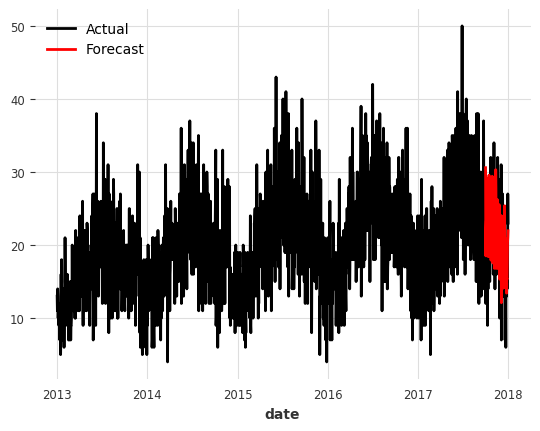

model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...) obtains MAPE: 25.43%


In [46]:
forecast = scaler.inverse_transform(model.predict(len(val)))
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()
eval_forecast(model, val, forecast);

Використовуючи к-сть лагів рівну 365 вдалось покращити показник помилки з наївної моделі: з 34% до 25%

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

In [47]:
from darts.models import ExponentialSmoothing, AutoARIMA, Theta

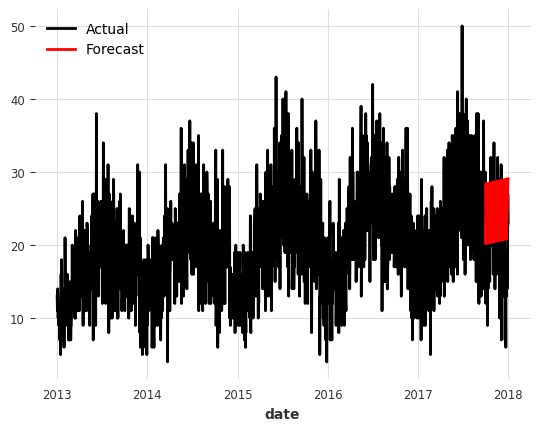

model ExponentialSmoothing() obtains MAPE: 39.01%


In [48]:
def plot_results(series, forecast):
  # Візуалізація результатів
  series.plot(label='Actual')
  forecast.plot(label='Forecast', color='red')
  plt.legend()
  plt.show()

def fit_and_plot(model, series, train, val):
  model.fit(train)
  forecast = model.predict(len(val))
  plot_results(series, forecast)
  eval_forecast(model, val, forecast);

model = ExponentialSmoothing()
fit_and_plot(model, series, train, val)

Дана модель найгірше зробила прогноз: межа помилки найвища серед усіх моделей

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

In [49]:
?ARIMA

Object `ARIMA` not found.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


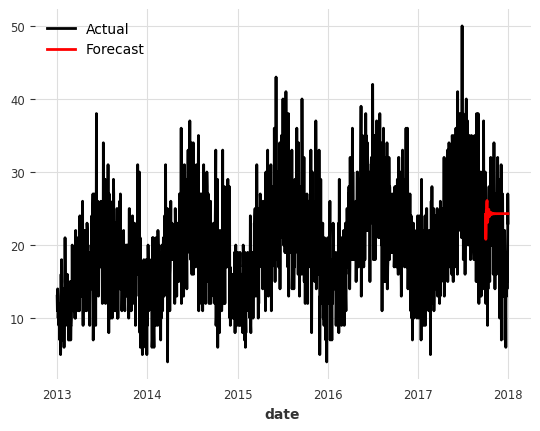

model ARIMA(p=7, q=1) obtains MAPE: 39.53%


In [50]:
from darts.models import ARIMA

# Побудова та тренування моделі ARIMA
model = ARIMA(p=7, d=1, q=1)
fit_and_plot(model, series, train, val)

При використанні лагу = 7 ми отримали дуже неякісну модель: рівень помилки перевищує 39% - це являється найгіршою моделлю

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, start_p=1, max_p=366, start_q=1)

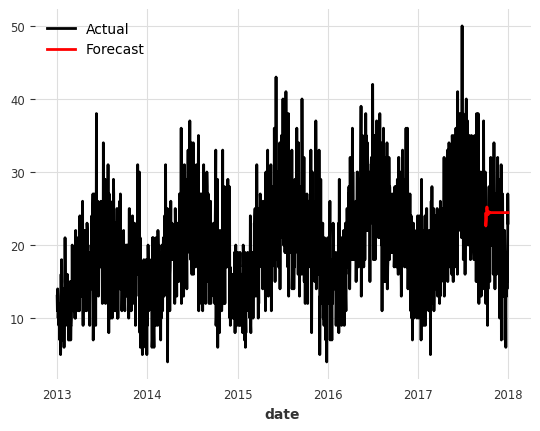

In [51]:
# Побудова та тренування моделі AutoArima
model = AutoARIMA(start_p=1, max_p=366, start_q=1) # спробуйте стартувати з інших значень і перегляньте, що виходить
model.fit(train)

display(model)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
plot_results(series, forecast)

In [52]:
eval_forecast(model, val, forecast);

model AutoARIMA(start_p=1, max_p=366, start_q=1) obtains MAPE: 40.29%


показники похибки не покращились порівнянно зі звичайною арімою

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/121ns5vg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/ne8vqgh8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94168', 'data', 'file=/tmp/tmp1s4rmiju/121ns5vg.json', 'init=/tmp/tmp1s4rmiju/ne8vqgh8.json', 'output', 'file=/tmp/tmp1s4rmiju/prophet_model76b2ap8g/prophet_model-20250906090941.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:09:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:09:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


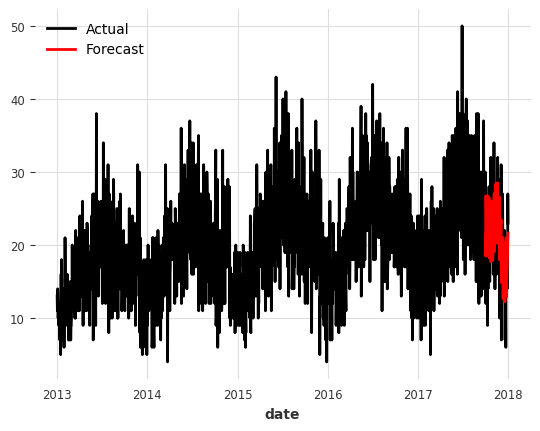

In [53]:
from darts.models import Prophet

# Побудова та тренування моделі Prophet
model = Prophet()
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [54]:
eval_forecast(model, val, forecast);

model Prophet() obtains MAPE: 23.80%


Показники похибки моделі зі всіх раніше побудованих являються найкращими

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 2.8 K  | train
6 | V               | Linear           | 26     | train
-------------------------------------------------------------
2.8 K     Trainable params
0         Non-trainable params
2.8 K     Total params
0.011     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

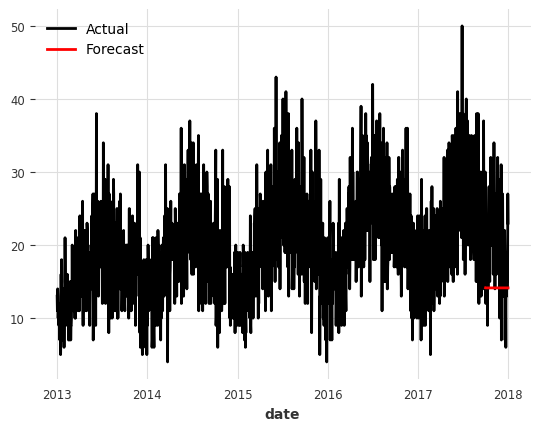

In [55]:
from darts.models import RNNModel

# Побудова та тренування моделі LSTM
model = RNNModel(model='LSTM', input_chunk_length=12, n_epochs=10)
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [58]:
eval_forecast(model, val, forecast);

model RNNModel(model=LSTM, input_chunk_length=12, n_epochs=10) obtains MAPE: 32.77%


Модель погіршилась порівняно з Prophet

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/zxk61tt8.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/f0u4jaf9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=23287', 'data', 'file=/tmp/tmp1s4rmiju/zxk61tt8.json', 'init=/tmp/tmp1s4rmiju/f0u4jaf9.json', 'output', 'file=/tmp/tmp1s4rmiju/prophet_model8d8hzf1v/prophet_model-20250906111051.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:10:51 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:10:52 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


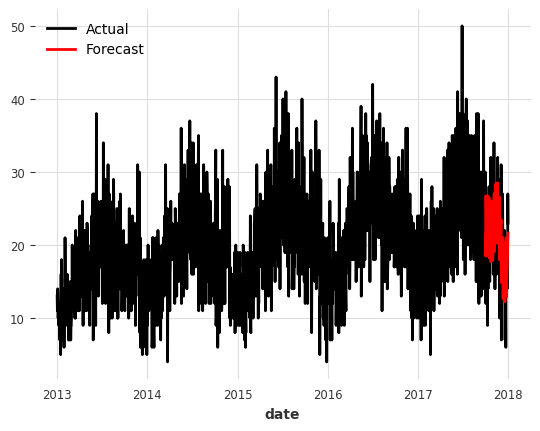

In [71]:
from darts.models import Prophet

# Побудова та тренування моделі Prophet
model = Prophet()
model.fit(train)

# Прогнозування
forecast = model.predict(len(val))

# Візуалізація результатів
series.plot(label='Actual')
forecast.plot(label='Forecast', color='red')
plt.legend()
plt.show()

In [72]:
eval_forecast(model, val, forecast);

model Prophet() obtains MAPE: 23.80%


Показано результат, скорочений до останніх рядків (5000).
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/bkp_kw8j.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38966', 'data', 'file=/tmp/tmp1s4rmiju/ofk8oiit.json', 'init=/tmp/tmp1s4rmiju/bkp_kw8j.json', 'output', 'file=/tmp/tmp1s4rmiju/prophet_modelof9bag0n/prophet_model-20250906112055.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:20:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:20:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
historical forecasts:  65%|██████▌   | 932/1431 [04:08<02:46,  2.99it/s]INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/mnif5ok0.json
DEBUG:cmdsta

MAPE = 23.77%


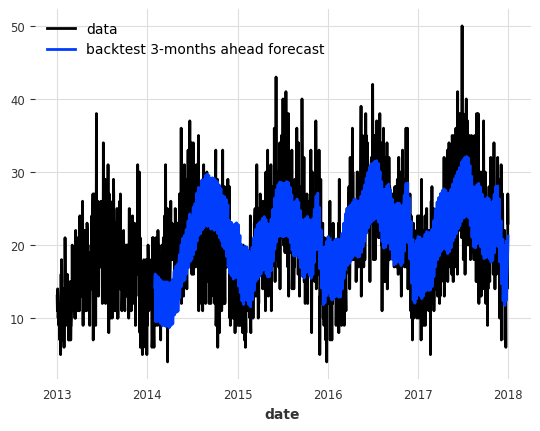

In [73]:
hfc_params = {
    "series": series,
    "start": pd.Timestamp("2014-01-01"),  # can also be a float for the fraction of the series to start at
    "forecast_horizon": 31,
    "verbose": True,
}

historical_fcast = model.historical_forecasts(last_points_only=True, **hfc_params)

series.plot(label="data")
historical_fcast.plot(label="backtest 3-months ahead forecast")
print(f"MAPE = {mape(series, historical_fcast):.2f}%")

historical forecasts:   0%|          | 0/47 [00:00<?, ?it/s]INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/k95d058q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp1s4rmiju/l9z9wl_9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=89393', 'data', 'file=/tmp/tmp1s4rmiju/k95d058q.json', 'init=/tmp/tmp1s4rmiju/l9z9wl_9.json', 'output', 'file=/tmp/tmp1s4rmiju/prophet_modelfv2pepjb/prophet_model-20250906114607.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:46:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:46:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain 

MAPE = 22.89%


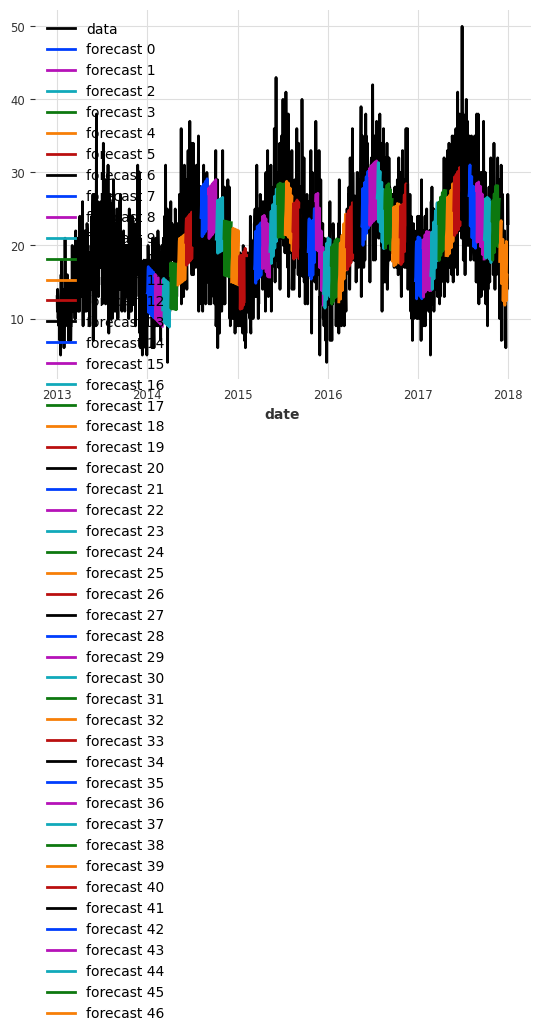

In [75]:
historical_fcast_all = model.historical_forecasts(last_points_only=False, stride=31, **hfc_params)

series.plot(label="data")
for idx, hfc in enumerate(historical_fcast_all):
    hfc.plot(label=f"forecast {idx}")

from darts import concatenate
historical_fcast_all = concatenate(historical_fcast_all, axis=0)
print(f"MAPE = {mape(series, historical_fcast_all):.2f}%")

Завдяки тому, що ми прогнозуємо на менший період - покращили показник помилки і зменшили його до 22,9%, але він не надто зменшився порівняно з попередніми результатом даної моделі, де ми розглядали прогноз на наступні три місяці

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Як один  з варіантів, це натренувати 500 моделей, де тренуємо окрему модель для кожного ряду(наприклад, ARIMA/SARIMA/Prophet для кожного ряду). Тут з плюсів, що кожен ряд тренується окремо і під кожен враховуються своя сезонність, але він являється дуже громіздким в плані навчання, оскільки навчити 500 моделей трудоресурсно

Саме тому альтернативою слугували б XGBoost/LSTM, оскільки це була б одна модель для всіх рядів + можна  використовувати додаткові ознаки: store_id, item_id, день тижня, святкові дні. Але складніше навчити, потрібно коректно усе підготувати